# 09 — ML Experiments and Model Selection

This notebook summarizes the Layer 9 wind forecasting experiments.

It compares baseline, Linear Regression, Random Forest, default GBT, tuned GBT, and the final production-candidate GBT model.

**Target:** `next_day_daily_region_capacity_factor`  
**Forecast horizon:** 1 day ahead  
**Final model:** Tuned Spark ML Gradient-Boosted Trees


## 1. Imports and Notebook Setup

This notebook uses local JSON artifacts written by the Layer 9 training scripts:

- `outputs/metrics/linear_regression_metrics.json`
- `outputs/metrics/random_forest_metrics.json`
- `outputs/metrics/gbt_metrics.json`
- `outputs/metrics/gbt_tuning_metrics.json`
- `outputs/metrics/final_gbt_test_metrics.json`
- `outputs/metrics/final_gbt_feature_importance.json`


In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

METRICS_DIR = Path('../outputs/metrics')
METRICS_DIR


PosixPath('../outputs/metrics')

## 2. Helper Functions


In [2]:
def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def maybe_load_json(path: Path):
    if path.exists():
        return load_json(path)
    print(f'Missing file: {path}')
    return None


def percent_improvement(old, new):
    return (old - new) / old * 100


## 3. Model Metric Summary

The values below come from the Layer 9 model training runs. If the JSON files are available locally, the notebook can be extended to load them directly. The table also includes the final test-set score from the production-candidate model.


In [3]:
model_metrics = pd.DataFrame([
    {
        'model': 'Baseline Mean',
        'stage': 'validation',
        'rmse': 0.05807741602045601,
        'mae': 0.03744208326183717,
    },
    {
        'model': 'Linear Regression',
        'stage': 'validation',
        'rmse': 0.0469036445754573,
        'mae': 0.027505033454691234,
    },
    {
        'model': 'Random Forest',
        'stage': 'validation',
        'rmse': 0.0468010653195115,
        'mae': 0.027590884566685556,
    },
    {
        'model': 'Default GBT',
        'stage': 'validation',
        'rmse': 0.046585201039092854,
        'mae': 0.02720615263799107,
    },
    {
        'model': 'Tuned GBT',
        'stage': 'validation',
        'rmse': 0.04650445810648858,
        'mae': 0.027172445083575716,
    },
    {
        'model': 'Final Tuned GBT',
        'stage': 'test',
        'rmse': 0.04202065582713153,
        'mae': 0.02566088425200168,
    },
])

model_metrics


,model,stage,rmse,mae
0,Baseline Mean,validation,0.058077,0.037442
1,Linear Regression,validation,0.046904,0.027505
2,Random Forest,validation,0.046801,0.027591
3,Default GBT,validation,0.046585,0.027206
4,Tuned GBT,validation,0.046504,0.027172
5,Final Tuned GBT,test,0.042021,0.025661


### Interpretation

The tree-based models outperform the baseline and Linear Regression. The tuned GBT has the strongest validation result, and the final model improves further on the test set after being trained on both training and validation data.


In [4]:
baseline_rmse = model_metrics.loc[model_metrics['model'] == 'Baseline Mean', 'rmse'].iloc[0]
baseline_mae = model_metrics.loc[model_metrics['model'] == 'Baseline Mean', 'mae'].iloc[0]

comparison = model_metrics.copy()
comparison['rmse_improvement_vs_baseline_pct'] = comparison['rmse'].apply(lambda x: percent_improvement(baseline_rmse, x))
comparison['mae_improvement_vs_baseline_pct'] = comparison['mae'].apply(lambda x: percent_improvement(baseline_mae, x))

comparison.sort_values(['stage', 'rmse'])


,model,stage,rmse,mae,rmse_improvement_vs_baseline_pct,mae_improvement_vs_baseline_pct
5,Final Tuned GBT,test,0.042021,0.025661,27.647167,31.465127
4,Tuned GBT,validation,0.046504,0.027172,19.926778,27.428063
3,Default GBT,validation,0.046585,0.027206,19.787752,27.338037
2,Random Forest,validation,0.046801,0.027591,19.416068,26.310498
1,Linear Regression,validation,0.046904,0.027505,19.239443,26.539789
0,Baseline Mean,validation,0.058077,0.037442,0.000000,0.000000


## 4. Visual Comparison of Models


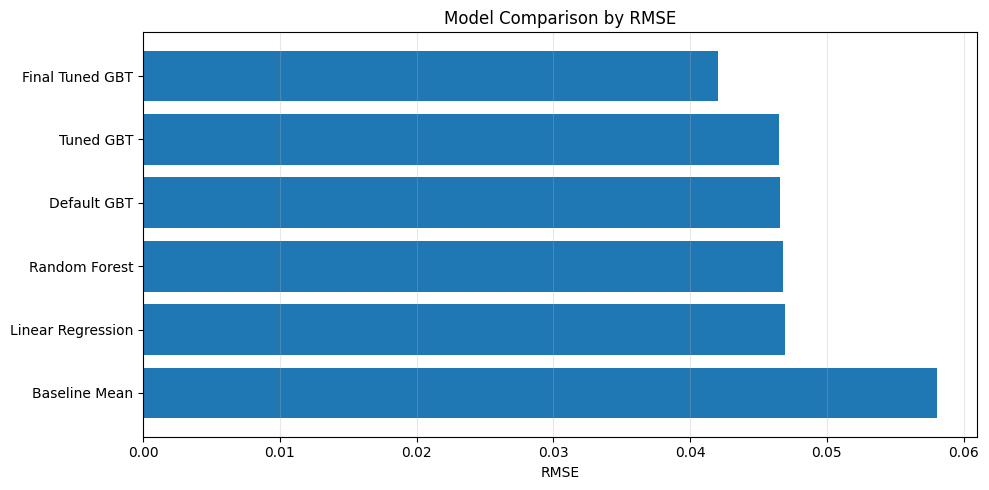

In [5]:
plot_df = model_metrics.sort_values('rmse', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(plot_df['model'], plot_df['rmse'])
plt.xlabel('RMSE')
plt.title('Model Comparison by RMSE')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


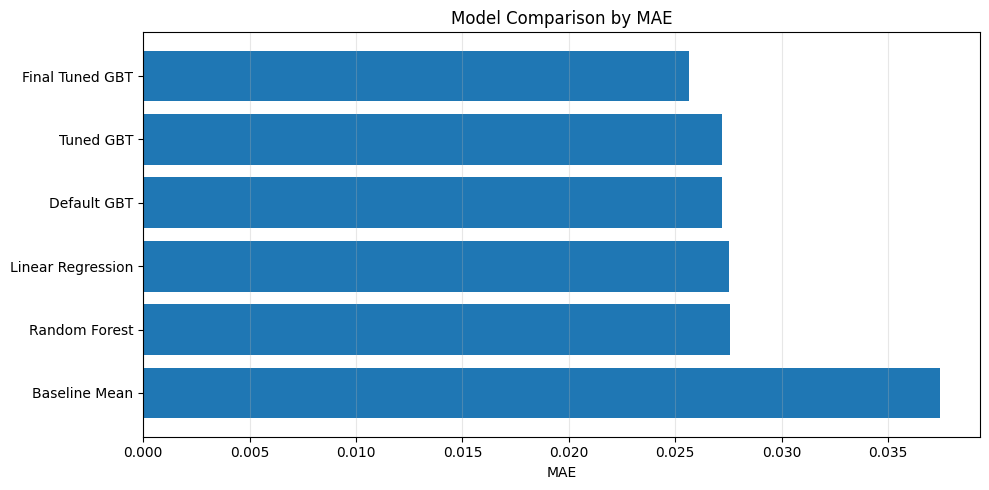

In [6]:
plot_df = model_metrics.sort_values('mae', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(plot_df['model'], plot_df['mae'])
plt.xlabel('MAE')
plt.title('Model Comparison by MAE')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Validation vs Test Performance

The final model is evaluated on the held-out test period only after model selection is complete. This keeps the test set as a true final evaluation set.


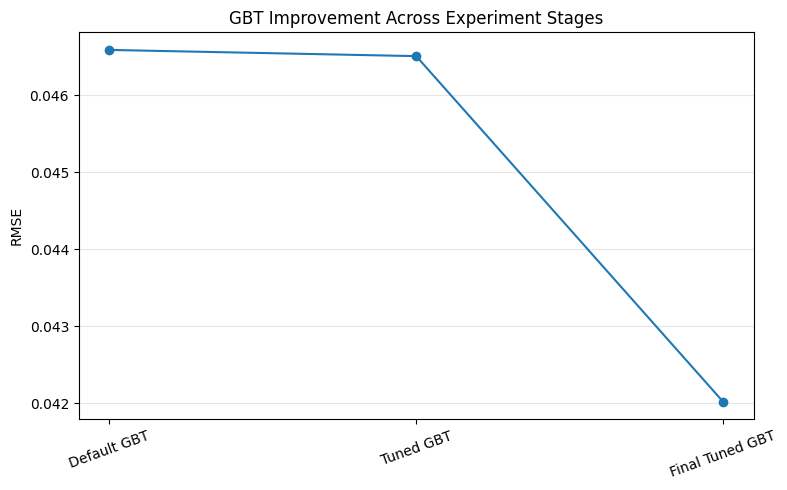

,model,stage,rmse,mae
3,Default GBT,validation,0.046585,0.027206
4,Tuned GBT,validation,0.046504,0.027172
5,Final Tuned GBT,test,0.042021,0.025661


In [7]:
gbt_progression = model_metrics[model_metrics['model'].isin(['Default GBT', 'Tuned GBT', 'Final Tuned GBT'])].copy()
gbt_progression['experiment_order'] = [1, 2, 3]
gbt_progression = gbt_progression.sort_values('experiment_order')

plt.figure(figsize=(8, 5))
plt.plot(gbt_progression['model'], gbt_progression['rmse'], marker='o')
plt.ylabel('RMSE')
plt.title('GBT Improvement Across Experiment Stages')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

gbt_progression[['model', 'stage', 'rmse', 'mae']]


## 6. GBT Hyperparameter Tuning Results

This section loads the tuning artifact if available and visualizes candidate performance.


In [8]:
tuning_path = METRICS_DIR / 'gbt_tuning_metrics.json'
tuning = maybe_load_json(tuning_path)

if tuning:
    tuning_rows = []
    for row in tuning['all_results']:
        params = row['params']
        metrics = row['metrics']
        tuning_rows.append({
            'max_iter': params['max_iter'],
            'max_depth': params['max_depth'],
            'step_size': params['step_size'],
            'rmse': metrics['rmse'],
            'mae': metrics['mae'],
            'training_seconds': row.get('training_seconds'),
        })
    tuning_df = pd.DataFrame(tuning_rows).sort_values('rmse')
else:
    tuning_df = pd.DataFrame([
        {'max_iter': 80, 'max_depth': 5, 'step_size': 0.05, 'rmse': 0.04650445810648858, 'mae': 0.027172445083575716, 'training_seconds': 117.9073},
        {'max_iter': 80, 'max_depth': 3, 'step_size': 0.1, 'rmse': 0.04653563329089327, 'mae': 0.0272653657235895, 'training_seconds': 69.2898},
        {'max_iter': 50, 'max_depth': 7, 'step_size': 0.05, 'rmse': 0.04654668684541781, 'mae': 0.027189557648880428, 'training_seconds': 123.7911},
        {'max_iter': 50, 'max_depth': 5, 'step_size': 0.1, 'rmse': 0.0465557600220508, 'mae': 0.027167568994046088, 'training_seconds': 71.3622},
    ])

tuning_df.head(10)


,max_iter,max_depth,step_size,rmse,mae,training_seconds
0,80,5,0.05,0.046504,0.027172,117.907323
1,80,3,0.10,0.046536,0.027265,69.289771
2,50,7,0.05,0.046547,0.027190,123.791083
3,50,5,0.10,0.046556,0.027168,71.362218
4,80,7,0.05,0.046557,0.027162,221.351089
5,80,5,0.10,0.046596,0.027048,118.153611
6,30,7,0.05,0.046630,0.027319,74.494667
7,30,5,0.10,0.046639,0.027322,46.671072
8,50,5,0.05,0.046662,0.027364,72.633355
9,30,7,0.10,0.046774,0.027215,71.311047


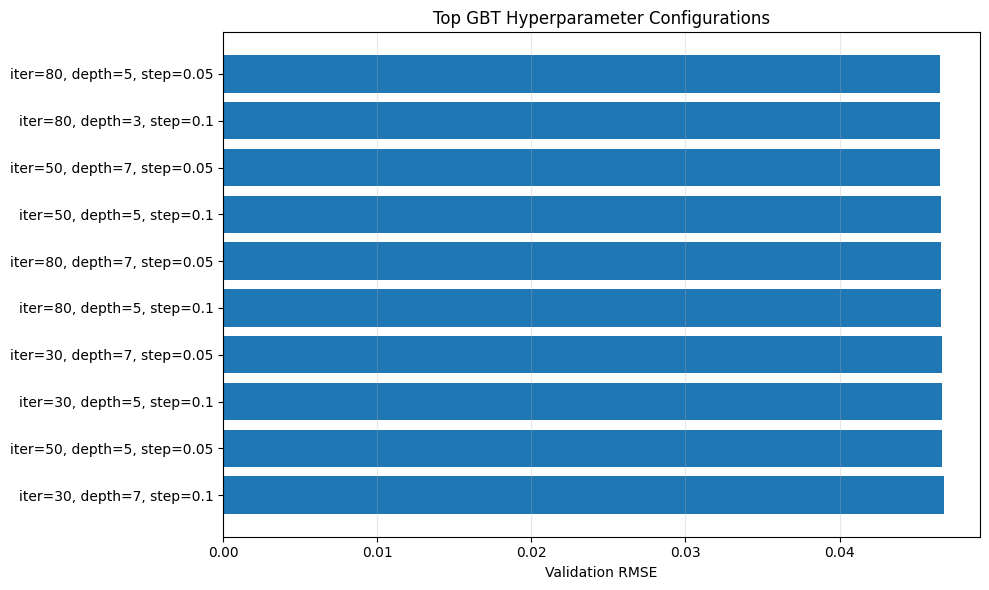

In [9]:
top_tuning = tuning_df.sort_values('rmse').head(10).copy()
top_tuning['config'] = (
    'iter=' + top_tuning['max_iter'].astype(str)
    + ', depth=' + top_tuning['max_depth'].astype(str)
    + ', step=' + top_tuning['step_size'].astype(str)
)

plt.figure(figsize=(10, 6))
plt.barh(top_tuning.sort_values('rmse', ascending=False)['config'], top_tuning.sort_values('rmse', ascending=False)['rmse'])
plt.xlabel('Validation RMSE')
plt.title('Top GBT Hyperparameter Configurations')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Feature Importance

Feature importance helps explain what the final GBT model used most heavily.


In [10]:
feature_path = METRICS_DIR / 'final_gbt_feature_importance.json'
feature_json = maybe_load_json(feature_path)

if feature_json:
    feature_importance = pd.DataFrame(feature_json['feature_importance'])
else:
    feature_importance = pd.DataFrame([
        {'feature': 'daily_region_capacity_factor', 'importance': 0.244051098035055},
        {'feature': 'day_of_year', 'importance': 0.08439755769400802},
        {'feature': 'avg_station_wind_speed_std_ms', 'importance': 0.08230558091715454},
        {'feature': 'daily_region_capacity_factor_rolling_30d_mean', 'importance': 0.08191177883109177},
        {'feature': 'state_long_run_volatility', 'importance': 0.05708329579980419},
        {'feature': 'state_long_run_avg_cf', 'importance': 0.05390466833223048},
        {'feature': 'cf_lag_1d', 'importance': 0.04800846657712132},
        {'feature': 'mean_region_wind_speed_ms', 'importance': 0.042241345841531754},
        {'feature': 'month', 'importance': 0.03786022325761487},
        {'feature': 'year', 'importance': 0.037732913890284984},
    ])

feature_importance.head(20)


,feature,importance
0,daily_region_capacity_factor,0.244051
1,day_of_year,0.084398
2,avg_station_wind_speed_std_ms,0.082306
3,daily_region_capacity_factor_rolling_30d_mean,0.081912
4,state_long_run_volatility,0.057083
5,state_long_run_avg_cf,0.053905
6,cf_lag_1d,0.048008
7,mean_region_wind_speed_ms,0.042241
8,month,0.037860
9,year,0.037733


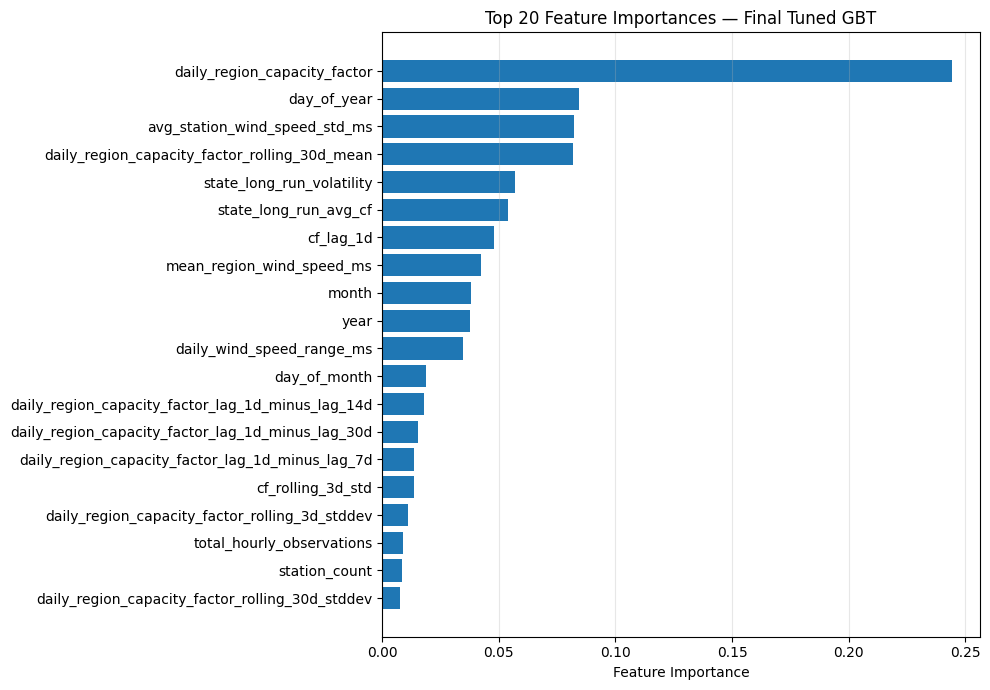

In [11]:
top_features = feature_importance.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_features.sort_values('importance')['feature'], top_features.sort_values('importance')['importance'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances — Final Tuned GBT')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Feature Importance Interpretation

The final model relies most heavily on:

- **Current wind potential:** `daily_region_capacity_factor`
- **Seasonality:** `day_of_year`, `month`
- **Short-term persistence:** lag features such as `cf_lag_1d`
- **Recent trend behavior:** rolling 30-day mean and rolling standard deviation features
- **Regional structure:** long-run state average and volatility

This is consistent with the physical intuition that wind potential is persistent, seasonal, regionally concentrated, and affected by recent variability.


## 8. Final Model Decision

The selected production candidate is:

**Model:** Tuned Spark ML Gradient-Boosted Trees  
**Hyperparameters:** `max_iter=80`, `max_depth=5`, `step_size=0.05`, `seed=42`  
**Test RMSE:** `0.04202`  
**Test MAE:** `0.02566`  

The tuned GBT model is selected because it provides the strongest overall predictive performance while preserving useful feature-importance interpretability.


## 9. Model Registry Record

Registered production-candidate version:

```text
final_tuned_gbt_20260504T063157Z
```

Registry location:

```text
s3a://syed-datsbd-s2026/models/registry/
```
